# XGBoost Training Pipeline — Prompt Injection Detection

**Dataset:** 399,741 samples, 35 features, balanced binary classification  
**Model:** XGBoost GPU (RTX 5070 / CUDA 13.2)  
**Optimization:** Optuna 100 trials, 5-fold CV, AUC-ROC maximization  

Run cells sequentially. Cell 6 (Optuna) takes ~30-40 min on GPU.

In [1]:
# CELL 1: Imports & Setup
import subprocess, sys
for pkg in ['xgboost>=2.0', 'optuna>=3.5', 'shap>=0.44']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
import shap
import json, pickle, os, time, warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('XGBoost: ', xgb.__version__)
print('Optuna:  ', optuna.__version__)
print('SHAP:    ', shap.__version__)

print('\nVerifying GPU...')
try:
    _dm = xgb.DMatrix([[1, 2], [3, 4]], label=[0, 1])
    xgb.train({'device': 'cuda', 'tree_method': 'hist', 'eval_metric': 'auc'},
               _dm, num_boost_round=1, verbose_eval=False)
    print('OK: XGBoost GPU (cuda) working')
except Exception as e:
    print('WARN: GPU unavailable:', e)
    print('  Set device="cpu" in CONFIG (Cell 2)')


XGBoost:  3.2.0
Optuna:   4.8.0
SHAP:     0.51.0

Verifying GPU...
OK: XGBoost GPU (cuda) working


In [2]:
# CELL 2: Configuration
CONFIG = {
    'data_path':          '/home/linkezio/Projects/IA-SI/data/features_engineered.csv',
    'original_data_path': '/home/linkezio/Datasets/prompt_injection_dataset.csv',
    'models_dir':         '/home/linkezio/Projects/IA-SI/models',
    'test_size': 0.20,
    'val_size':  0.20,
    'cv_folds':  5,
    'seed':      42,
    'n_trials':   100,
    'study_name': 'xgboost_prompt_injection_v1',
    'device':                'cuda',
    'tree_method':           'hist',
    'eval_metric':           'auc',
    'early_stopping_rounds': 50,
    'hp': {
        'n_estimators':     (300,  3000),
        'max_depth':        (3,    10),
        'learning_rate':    (0.005, 0.3),
        'subsample':        (0.5,  1.0),
        'colsample_bytree': (0.5,  1.0),
        'min_child_weight': (1,    15),
        'gamma':            (1e-8, 5.0),
        'reg_alpha':        (1e-8, 10.0),
        'reg_lambda':       (1e-8, 10.0),
    },
}
os.makedirs(CONFIG['models_dir'], exist_ok=True)
print('Models directory ready:', CONFIG['models_dir'])
print('Device:', CONFIG['device'], '| Trials:', CONFIG['n_trials'])


Models directory ready: /home/linkezio/Projects/IA-SI/models
Device: cuda | Trials: 100


In [3]:
# CELL 3: Data Loading & Preprocessing
df = pd.read_csv(CONFIG['data_path'])
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
assert df.shape[1] == 36, f'Expected 36 columns, got {df.shape[1]}'
assert 'label' in df.columns
assert df['label'].nunique() == 2

nulls = df.isnull().sum()
print('Nulls before preprocessing:')
print(nulls[nulls > 0].to_string() if nulls.sum() > 0 else '  None')

median_ld = df['lexical_diversity'].median()
df['lexical_diversity'] = df['lexical_diversity'].fillna(median_ld)
print(f'Filled lexical_diversity nulls with median = {median_ld:.6f}')

p99_cpr = df['comma_to_period_ratio'].quantile(0.99)
df['comma_to_period_ratio'] = df['comma_to_period_ratio'].clip(upper=p99_cpr)
print(f'Clipped comma_to_period_ratio at 99th pct = {p99_cpr:.4f}')

assert df.isnull().sum().sum() == 0, 'Unexpected nulls after preprocessing'
print('Zero nulls after preprocessing')
print('\nClass distribution:')
print(df['label'].value_counts().to_string())
print(df['label'].value_counts(normalize=True).round(4).to_string())


Loaded: 399,741 rows x 36 columns
Nulls before preprocessing:
lexical_diversity    124
Filled lexical_diversity nulls with median = 1.041393
Clipped comma_to_period_ratio at 99th pct = 3.5000
Zero nulls after preprocessing

Class distribution:
label
0    203067
1    196674
label
0    0.508
1    0.492


In [4]:
# CELL 4: Train/Test Split
FEATURE_COLS = [c for c in df.columns if c != 'label']
X = df[FEATURE_COLS].reset_index(drop=True)
y = df['label'].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], stratify=y, random_state=CONFIG['seed']
)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'Train set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print('Train class dist:', y_train.value_counts(normalize=True).round(4).to_dict())
print('Test  class dist:', y_test.value_counts(normalize=True).round(4).to_dict())
assert abs(y_train.mean() - y_test.mean()) < 0.01, 'Stratification failed'
print('Stratification check passed')
print('Features:', len(FEATURE_COLS))


Train set: 319,792 samples (80.0%)
Test set:  79,949 samples (20.0%)
Train class dist: {0: 0.508, 1: 0.492}
Test  class dist: {0: 0.508, 1: 0.492}
Stratification check passed
Features: 35


In [5]:
# CELL 5: Optuna Objective Function
def objective(trial):
    """5-fold stratified CV, returns mean AUC-ROC. GPU-accelerated."""
    params = {
        'n_estimators':     trial.suggest_int('n_estimators',     *CONFIG['hp']['n_estimators']),
        'max_depth':        trial.suggest_int('max_depth',        *CONFIG['hp']['max_depth']),
        'learning_rate':    trial.suggest_float('learning_rate',  *CONFIG['hp']['learning_rate'],  log=True),
        'subsample':        trial.suggest_float('subsample',      *CONFIG['hp']['subsample']),
        'colsample_bytree': trial.suggest_float('colsample_bytree', *CONFIG['hp']['colsample_bytree']),
        'min_child_weight': trial.suggest_int('min_child_weight', *CONFIG['hp']['min_child_weight']),
        'gamma':            trial.suggest_float('gamma',          *CONFIG['hp']['gamma'],      log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha',      *CONFIG['hp']['reg_alpha'],  log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda',     *CONFIG['hp']['reg_lambda'], log=True),
        'device':       CONFIG['device'],
        'tree_method':  CONFIG['tree_method'],
        'eval_metric':  CONFIG['eval_metric'],
        'random_state': CONFIG['seed'],
        'verbosity':    0,
        'early_stopping_rounds': CONFIG['early_stopping_rounds'],
    }
    cv = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=CONFIG['seed'])
    fold_aucs = []
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        model = xgb.XGBClassifier(**params)
        model.fit(
            X_train.iloc[tr_idx], y_train.iloc[tr_idx],
            eval_set=[(X_train.iloc[val_idx], y_train.iloc[val_idx])],
            verbose=False,
        )
        proba = model.predict_proba(X_train.iloc[val_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y_train.iloc[val_idx], proba))
        trial.report(np.mean(fold_aucs), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_aucs))

print('Optuna objective defined')
print(f'  CV folds: {CONFIG["cv_folds"]}, early stopping: {CONFIG["early_stopping_rounds"]}')
print('  Primary metric: AUC-ROC (maximize)')
print('\nSmoke test (1 trial)...')
_st = optuna.create_study(direction='maximize')
_st.optimize(objective, n_trials=1, show_progress_bar=False)
print(f'Smoke test passed - AUC: {_st.best_value:.4f}')

Optuna objective defined
  CV folds: 5, early stopping: 50
  Primary metric: AUC-ROC (maximize)

Smoke test (1 trial)...
Smoke test passed - AUC: 0.9180


Starting Optuna: 100 trials, 5-fold CV
device=cuda, tree_method=hist


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna Search Complete - 27.8 minutes
Best 5-fold AUC-ROC: 0.918307
Best trial #:        93
Completed: 50 | Pruned: 50

Best hyperparameters:
  colsample_bytree          0.9357172033114852
  gamma                     0.006117370332564055
  learning_rate             0.014235493896663919
  max_depth                 8
  min_child_weight          1
  n_estimators              2639
  reg_alpha                 0.8675209730541205
  reg_lambda                9.856183844864679e-08
  subsample                 0.8461250191408909


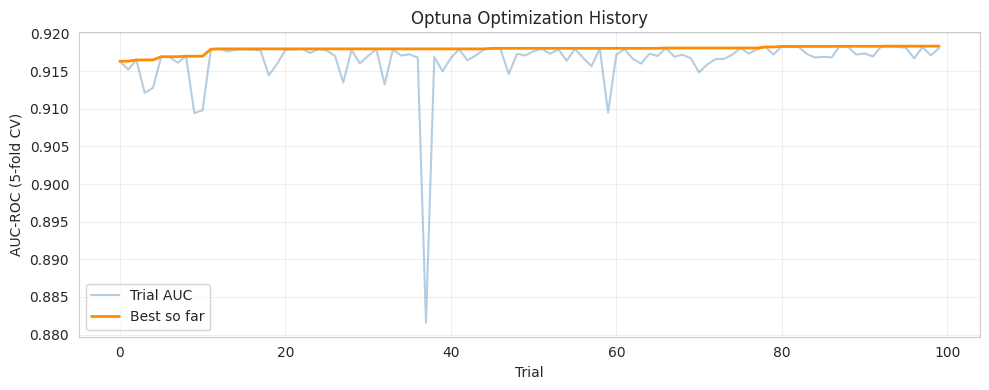

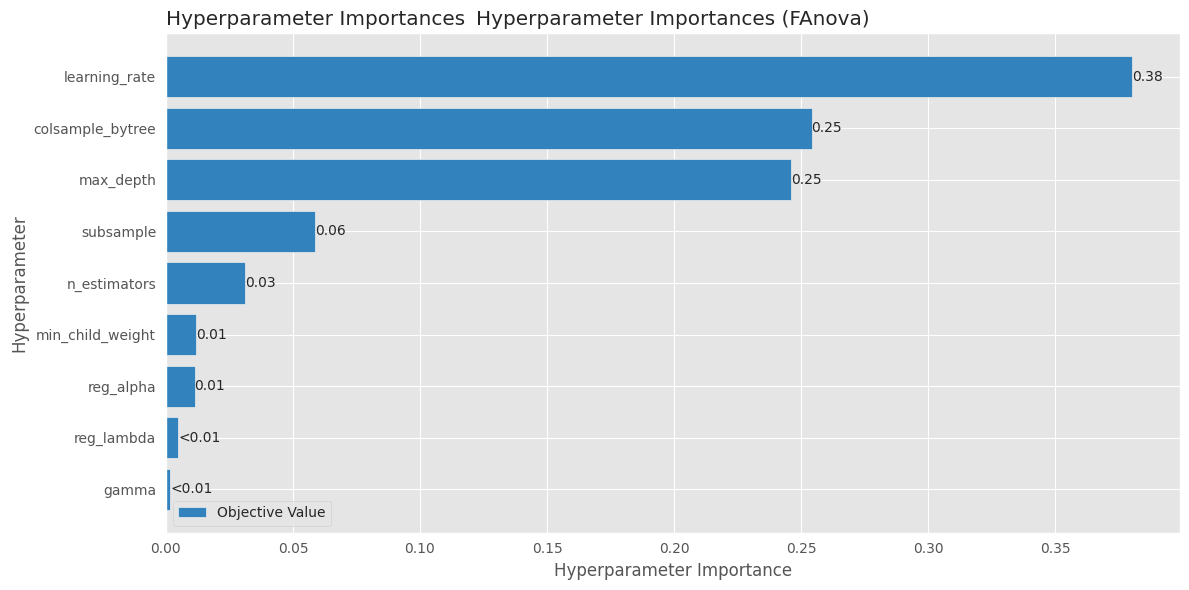

In [6]:
# CELL 6: Optuna Hyperparameter Search (~30-40 min on GPU)
print(f'Starting Optuna: {CONFIG["n_trials"]} trials, {CONFIG["cv_folds"]}-fold CV')
print(f'device={CONFIG["device"]}, tree_method={CONFIG["tree_method"]}')

study = optuna.create_study(
    direction='maximize',
    study_name=CONFIG['study_name'],
    sampler=optuna.samplers.TPESampler(seed=CONFIG['seed']),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)
t0 = time.time()
study.optimize(objective, n_trials=CONFIG['n_trials'], show_progress_bar=True)
elapsed_min = (time.time() - t0) / 60

n_complete = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
n_pruned   = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
print('=' * 60)
print(f'Optuna Search Complete - {elapsed_min:.1f} minutes')
print('=' * 60)
print(f'Best 5-fold AUC-ROC: {study.best_value:.6f}')
print(f'Best trial #:        {study.best_trial.number}')
print(f'Completed: {n_complete} | Pruned: {n_pruned}')
print('\nBest hyperparameters:')
for k, v in sorted(study.best_params.items()):
    print(f'  {k:<25} {v}')

fig1, ax1 = plt.subplots(figsize=(10, 4))
values = [t.value for t in study.trials if t.value is not None]
ax1.plot(values, alpha=0.4, color='steelblue', label='Trial AUC')
ax1.plot(pd.Series(values).cummax().values, color='darkorange', lw=2, label='Best so far')
ax1.set_xlabel('Trial'); ax1.set_ylabel('AUC-ROC (5-fold CV)')
ax1.set_title('Optuna Optimization History'); ax1.legend(); ax1.grid(alpha=0.3)
plt.tight_layout(); plt.show()

try:
    optuna.visualization.matplotlib.plot_param_importances(study)
    plt.title('Hyperparameter Importances (FAnova)'); plt.tight_layout(); plt.show()
except Exception as e:
    print(f'(Param importance plot skipped: {e})')


In [7]:
# CELL 7: Final Model Training
best_params = {**study.best_params}
best_params.update({
    'device': CONFIG['device'], 'tree_method': CONFIG['tree_method'],
    'eval_metric': CONFIG['eval_metric'], 'random_state': CONFIG['seed'], 'verbosity': 0,
    'early_stopping_rounds': CONFIG['early_stopping_rounds'],
})

X_tr, X_es_val, y_tr, y_es_val = train_test_split(
    X_train, y_train, test_size=CONFIG['val_size'],
    stratify=y_train, random_state=CONFIG['seed']
)
print('Final model training')
print(f'  Train: {X_tr.shape[0]:,} | Early-stop val: {X_es_val.shape[0]:,} (internal, not holdout)')
print(f'  Max trees: {best_params["n_estimators"]} | Early stopping: {CONFIG["early_stopping_rounds"]} rounds')

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(
    X_tr, y_tr,
    eval_set=[(X_es_val, y_es_val)],
    verbose=100,
)
print('Training complete')
print(f'  Best iteration (trees): {final_model.best_iteration}')
print(f'  Early-stop val AUC:     {final_model.best_score:.6f}')

Final model training
  Train: 255,833 | Early-stop val: 63,959 (internal, not holdout)
  Max trees: 2639 | Early stopping: 50 rounds
[0]	validation_0-auc:0.88995
[100]	validation_0-auc:0.90111
[200]	validation_0-auc:0.90428
[300]	validation_0-auc:0.90681
[400]	validation_0-auc:0.90868
[500]	validation_0-auc:0.91056
[600]	validation_0-auc:0.91204
[700]	validation_0-auc:0.91320
[800]	validation_0-auc:0.91400
[900]	validation_0-auc:0.91461
[1000]	validation_0-auc:0.91510
[1100]	validation_0-auc:0.91546
[1200]	validation_0-auc:0.91576
[1300]	validation_0-auc:0.91603
[1400]	validation_0-auc:0.91627
[1500]	validation_0-auc:0.91644
[1600]	validation_0-auc:0.91660
[1700]	validation_0-auc:0.91667
[1800]	validation_0-auc:0.91675
[1900]	validation_0-auc:0.91681
[2000]	validation_0-auc:0.91686
[2100]	validation_0-auc:0.91693
[2200]	validation_0-auc:0.91695
[2300]	validation_0-auc:0.91695
[2400]	validation_0-auc:0.91698
[2447]	validation_0-auc:0.91697
Training complete
  Best iteration (trees): 239

HOLDOUT TEST SET EVALUATION
  AUC-ROC  (primary) : 0.918043
  AUC-PR             : 0.928564
  Accuracy           : 0.826552
  Precision          : 0.860737
  Recall             : 0.772442
  F1 Score           : 0.814202
  TN=35,698  FP=4,916  FN=8,951  TP=30,384

               precision    recall  f1-score   support

   Benign (0)       0.80      0.88      0.84     40614
Injection (1)       0.86      0.77      0.81     39335

     accuracy                           0.83     79949
    macro avg       0.83      0.83      0.83     79949
 weighted avg       0.83      0.83      0.83     79949



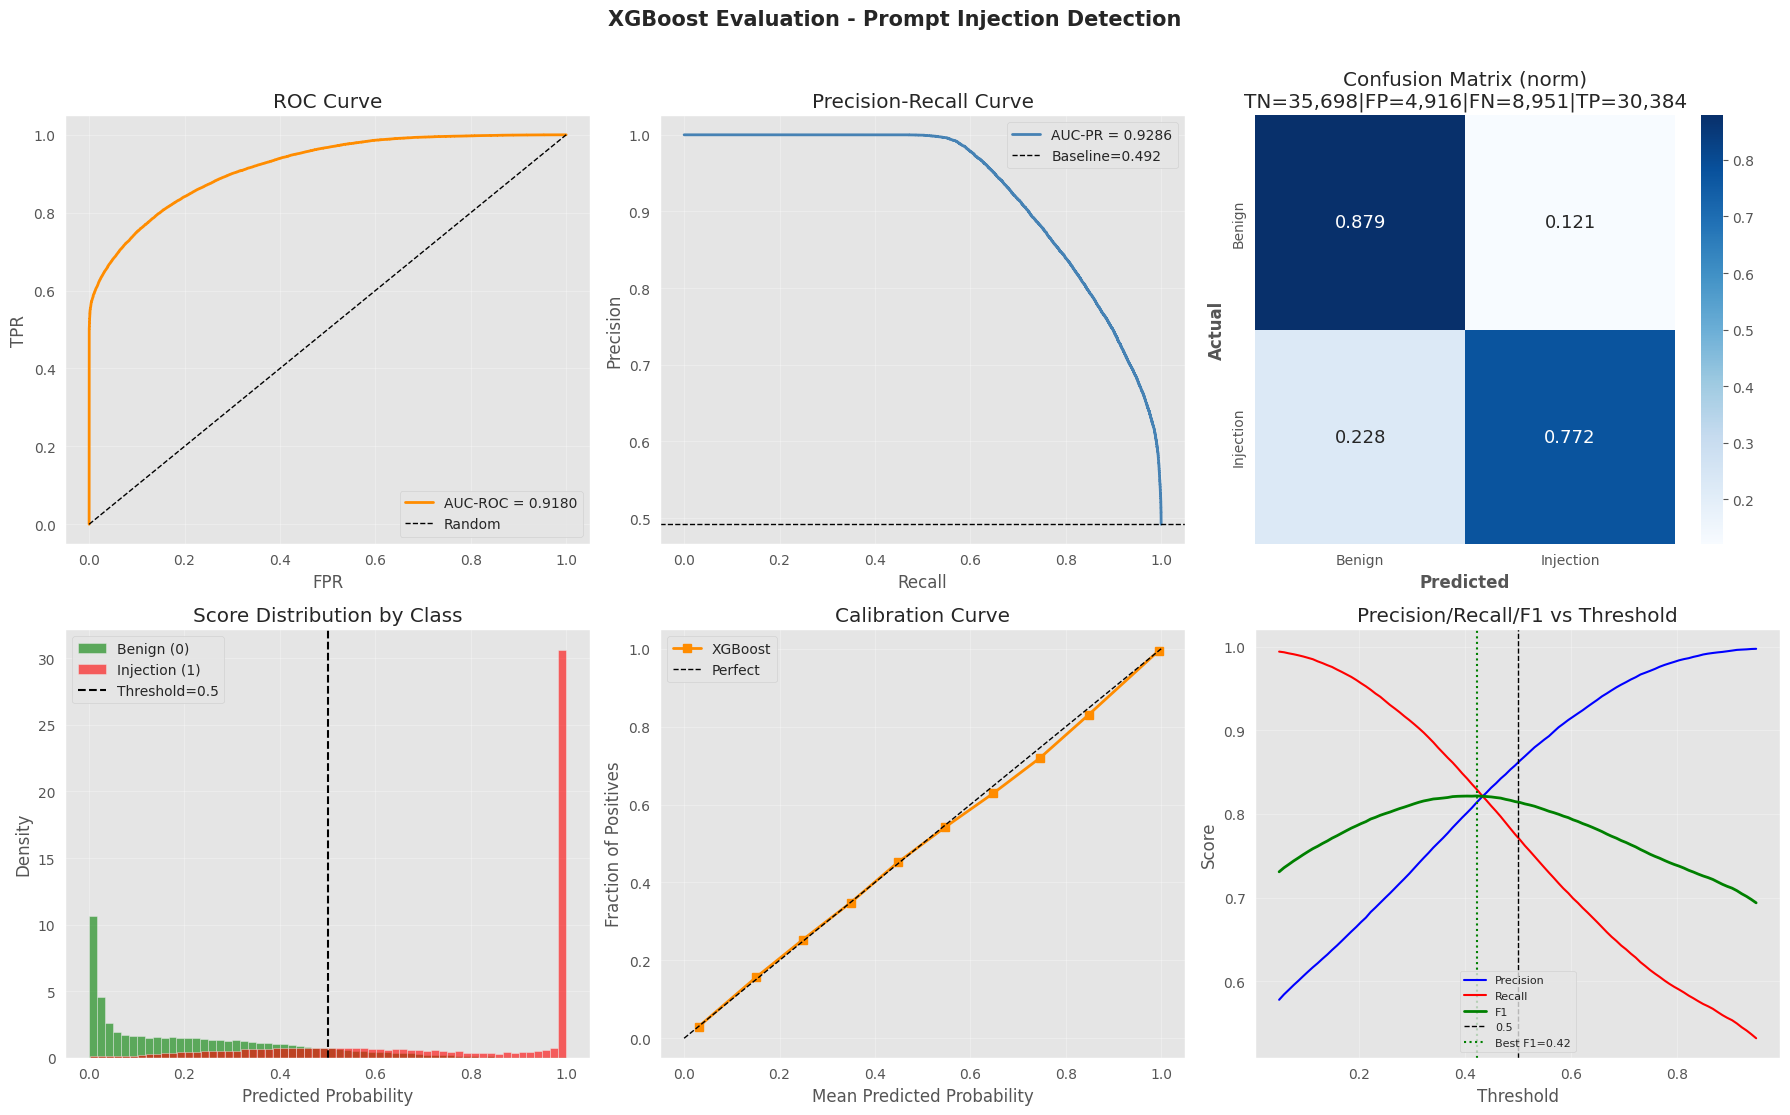

Evaluation plot saved: /home/linkezio/Projects/IA-SI/models/evaluation_plots.png


In [8]:
# CELL 8: Full Evaluation on Holdout Test Set
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred       = final_model.predict(X_test)

auc_roc = roc_auc_score(y_test, y_pred_proba)
auc_pr  = average_precision_score(y_test, y_pred_proba)
acc     = accuracy_score(y_test, y_pred)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
cm      = confusion_matrix(y_test, y_pred)

print('=' * 56)
print('HOLDOUT TEST SET EVALUATION')
print('=' * 56)
print(f'  AUC-ROC  (primary) : {auc_roc:.6f}')
print(f'  AUC-PR             : {auc_pr:.6f}')
print(f'  Accuracy           : {acc:.6f}')
print(f'  Precision          : {prec:.6f}')
print(f'  Recall             : {rec:.6f}')
print(f'  F1 Score           : {f1:.6f}')
print(f'  TN={cm[0,0]:,}  FP={cm[0,1]:,}  FN={cm[1,0]:,}  TP={cm[1,1]:,}')
print()
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Injection (1)']))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('XGBoost Evaluation - Prompt Injection Detection', fontsize=15, fontweight='bold', y=1.01)

# Panel 1: ROC
ax = axes[0, 0]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC-ROC = {auc_roc:.4f}')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curve')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)

# Panel 2: PR
ax = axes[0, 1]
pv, rv, _ = precision_recall_curve(y_test, y_pred_proba)
ax.plot(rv, pv, color='steelblue', lw=2, label=f'AUC-PR = {auc_pr:.4f}')
ax.axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label=f'Baseline={y_test.mean():.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Precision-Recall Curve')
ax.legend(); ax.grid(alpha=0.3)

# Panel 3: Confusion Matrix
ax = axes[0, 2]
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            xticklabels=['Benign','Injection'], yticklabels=['Benign','Injection'],
            annot_kws={'size': 13})
ax.set_ylabel('Actual', fontweight='bold'); ax.set_xlabel('Predicted', fontweight='bold')
ax.set_title(f'Confusion Matrix (norm)\nTN={cm[0,0]:,}|FP={cm[0,1]:,}|FN={cm[1,0]:,}|TP={cm[1,1]:,}')

# Panel 4: Score distribution
ax = axes[1, 0]
ax.hist(y_pred_proba[y_test==0], bins=60, alpha=0.6, color='green', label='Benign (0)', density=True)
ax.hist(y_pred_proba[y_test==1], bins=60, alpha=0.6, color='red',   label='Injection (1)', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
ax.set_title('Score Distribution by Class'); ax.legend(); ax.grid(alpha=0.3)

# Panel 5: Calibration
ax = axes[1, 1]
frac_pos, mean_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)
ax.plot(mean_pred, frac_pos, 's-', color='darkorange', lw=2, label='XGBoost')
ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve'); ax.legend(); ax.grid(alpha=0.3)

# Panel 6: Threshold analysis
ax = axes[1, 2]
thresholds_arr = np.linspace(0.05, 0.95, 100)
t_prec, t_rec, t_f1 = [], [], []
for t in thresholds_arr:
    y_t = (y_pred_proba >= t).astype(int)
    t_prec.append(precision_score(y_test, y_t, zero_division=0))
    t_rec.append(recall_score(y_test, y_t, zero_division=0))
    t_f1.append(f1_score(y_test, y_t, zero_division=0))
ax.plot(thresholds_arr, t_prec, label='Precision', color='blue', lw=1.5)
ax.plot(thresholds_arr, t_rec,  label='Recall',    color='red',  lw=1.5)
ax.plot(thresholds_arr, t_f1,   label='F1',        color='green', lw=2)
best_f1t = thresholds_arr[np.argmax(t_f1)]
ax.axvline(x=0.5, color='black', linestyle='--', lw=1, label='0.5')
ax.axvline(x=best_f1t, color='green', linestyle=':', lw=1.5, label=f'Best F1={best_f1t:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Precision/Recall/F1 vs Threshold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(CONFIG['models_dir'], 'evaluation_plots.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Evaluation plot saved: {plot_path}')


Loading original texts for error analysis...
Label alignment verified (79,949 test samples)
ERROR ANALYSIS - 79,949 test samples
  False Positives (benign->injection): 4,916  (6.15%)
  False Negatives (injection->benign): 8,951  (11.20%)
  Correct (benign):    35,698
  Correct (injection): 30,384

--- TOP 5 FALSE POSITIVES (benign->injection, highest confidence) ---

[FP #1] Score=0.9988
  write a regex expression that find graphql queries or mutations in a file

[FP #2] Score=0.9984
  Create a mnemonic device to remember "Education is impossible to forget"

[FP #3] Score=0.9978
  hello chatgpt. i want you to act like me. i am a expert tone analyzer and i can tell tones from text with percision. i want you to replicate my skills and provide four percentages for tone being: toxicty,  rude, kind, appropriate ( for context ). in 

[FP #4] Score=0.9973
  please create a plan for new beauty product development as a brand manager

[FP #5] Score=0.9966
  simulate a panel conversation between 

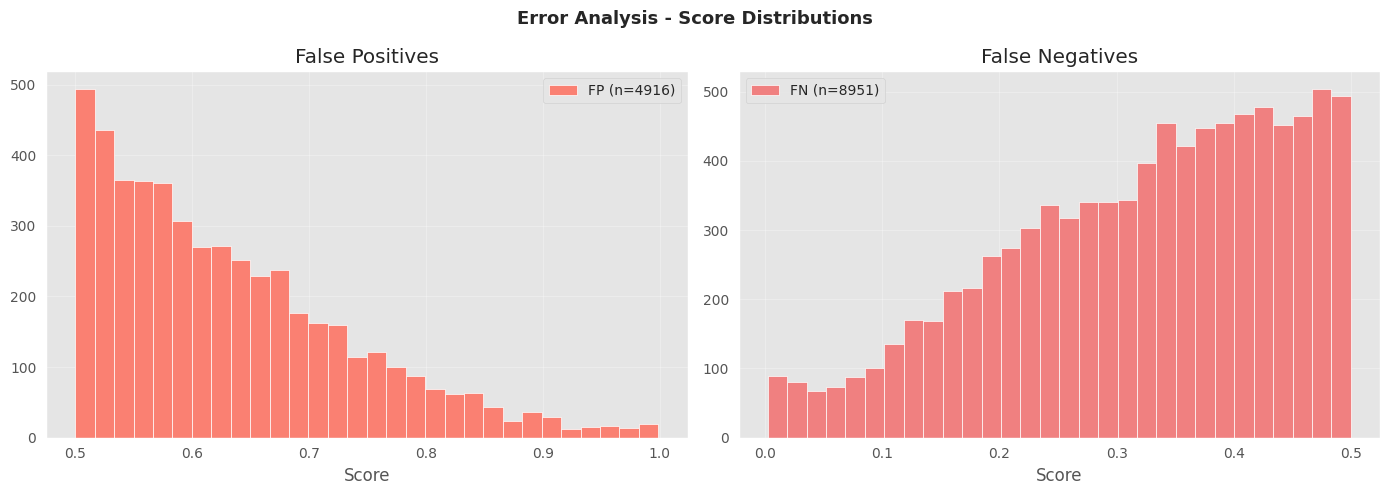

In [9]:
# CELL 9: Error Analysis
print('Loading original texts for error analysis...')
df_orig = pd.read_csv(CONFIG['original_data_path'])
if 'prompt' in df_orig.columns and 'text' not in df_orig.columns:
    df_orig = df_orig.rename(columns={'prompt': 'text'})
df_orig = df_orig[['text', 'label']].reset_index(drop=True)

_, df_orig_test = train_test_split(
    df_orig, test_size=CONFIG['test_size'],
    stratify=df_orig['label'], random_state=CONFIG['seed']
)
df_orig_test = df_orig_test.reset_index(drop=True)

assert (df_orig_test['label'].values == y_test.values).all(), \
    'Label mismatch between feature CSV and original dataset - check split parameters'
print(f'Label alignment verified ({len(df_orig_test):,} test samples)')

df_errors = df_orig_test.copy()
df_errors['y_pred_proba'] = y_pred_proba
df_errors['y_pred'] = y_pred

fps              = df_errors[(df_errors['label']==0)&(df_errors['y_pred']==1)].sort_values('y_pred_proba', ascending=False)
fns              = df_errors[(df_errors['label']==1)&(df_errors['y_pred']==0)].sort_values('y_pred_proba', ascending=True)
correct_benign   = df_errors[(df_errors['label']==0)&(df_errors['y_pred']==0)]
correct_injection = df_errors[(df_errors['label']==1)&(df_errors['y_pred']==1)]

n_test = len(df_errors)
print('=' * 60)
print(f'ERROR ANALYSIS - {n_test:,} test samples')
print('=' * 60)
print(f'  False Positives (benign->injection): {len(fps):,}  ({len(fps)/n_test*100:.2f}%)')
print(f'  False Negatives (injection->benign): {len(fns):,}  ({len(fns)/n_test*100:.2f}%)')
print(f'  Correct (benign):    {len(correct_benign):,}')
print(f'  Correct (injection): {len(correct_injection):,}')

print('\n--- TOP 5 FALSE POSITIVES (benign->injection, highest confidence) ---')
for i, (_, row) in enumerate(fps.head(5).iterrows(), 1):
    print(f'\n[FP #{i}] Score={row["y_pred_proba"]:.4f}')
    print(f'  {str(row["text"])[:250]}')

print('\n--- TOP 5 FALSE NEGATIVES (injection->benign, lowest score) ---')
for i, (_, row) in enumerate(fns.head(5).iterrows(), 1):
    print(f'\n[FN #{i}] Score={row["y_pred_proba"]:.4f}')
    print(f'  {str(row["text"])[:250]}')

print('\n--- FEATURE PROFILE: error groups vs. correctly classified ---')
diag_feats = ['total_injection_keywords','keyword_density','entropy',
               'uppercase_ratio','type_token_ratio','text_length','has_override_keyword']
print(f'{"Feature":<32} {"FP":>8} {"Correct-B":>10} {"FN":>8} {"Correct-I":>10}')
print('-' * 72)
for feat in diag_feats:
    fp_m = X_test.loc[fps.index, feat].mean()               if len(fps) > 0              else float('nan')
    cb_m = X_test.loc[correct_benign.index, feat].mean()    if len(correct_benign) > 0   else float('nan')
    fn_m = X_test.loc[fns.index, feat].mean()               if len(fns) > 0              else float('nan')
    ci_m = X_test.loc[correct_injection.index, feat].mean() if len(correct_injection) > 0 else float('nan')
    print(f'  {feat:<30} {fp_m:>8.4f} {cb_m:>10.4f} {fn_m:>8.4f} {ci_m:>10.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis - Score Distributions', fontsize=13, fontweight='bold')
axes[0].hist(fps['y_pred_proba'], bins=30, color='salmon', edgecolor='white', label=f'FP (n={len(fps)})')
axes[0].set_title('False Positives'); axes[0].set_xlabel('Score'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(fns['y_pred_proba'], bins=30, color='lightcoral', edgecolor='white', label=f'FN (n={len(fns)})')
axes[1].set_title('False Negatives'); axes[1].set_xlabel('Score'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


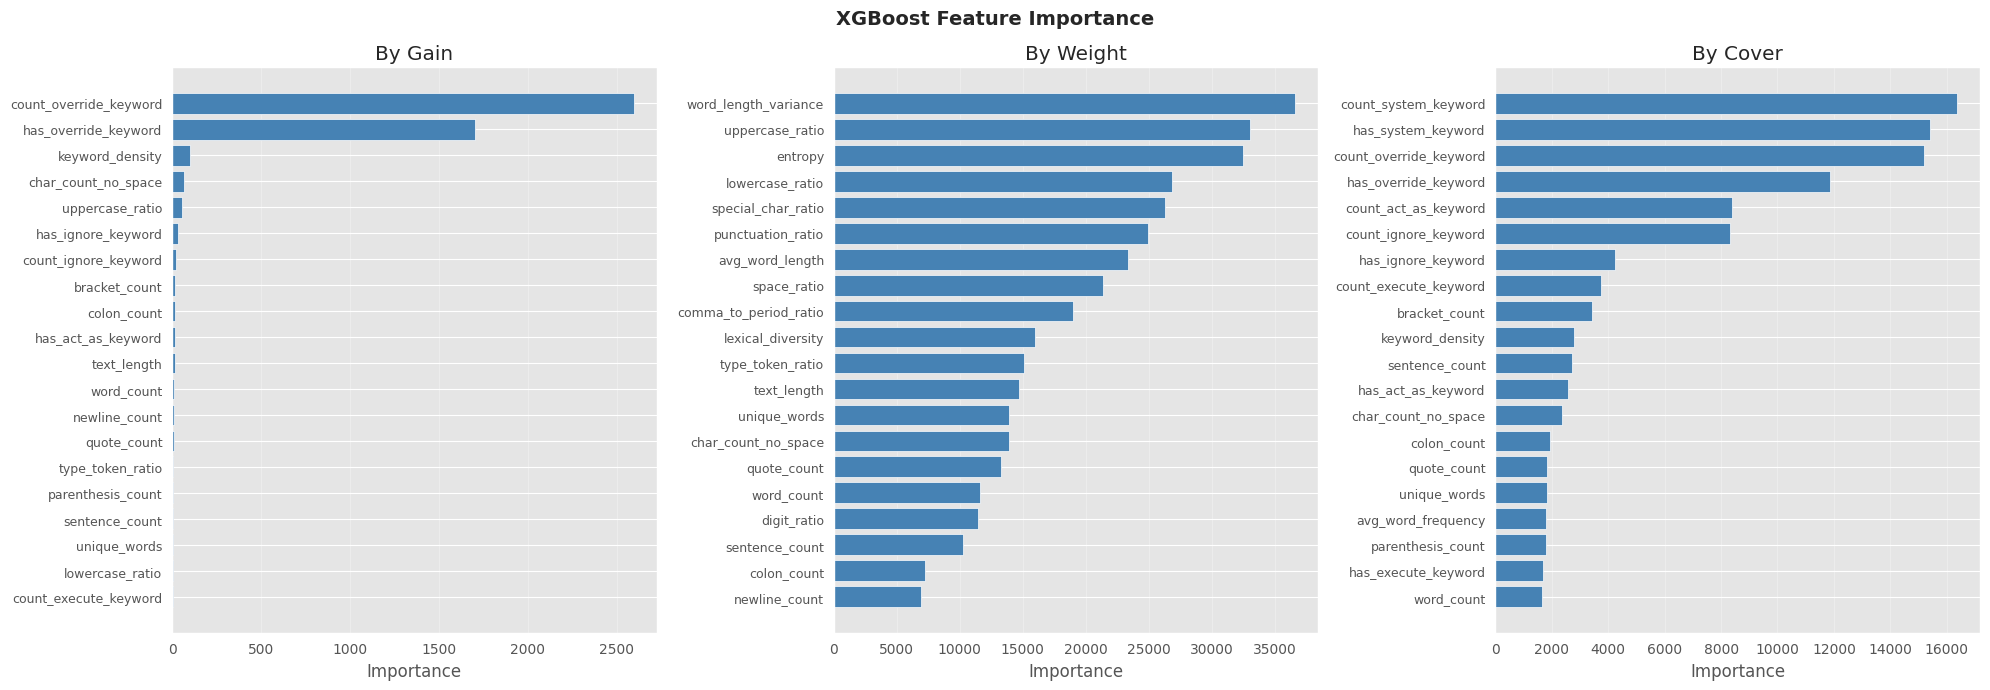

Feature importance saved: /home/linkezio/Projects/IA-SI/models/feature_importance.png
Computing SHAP values on 2,000-sample subset...


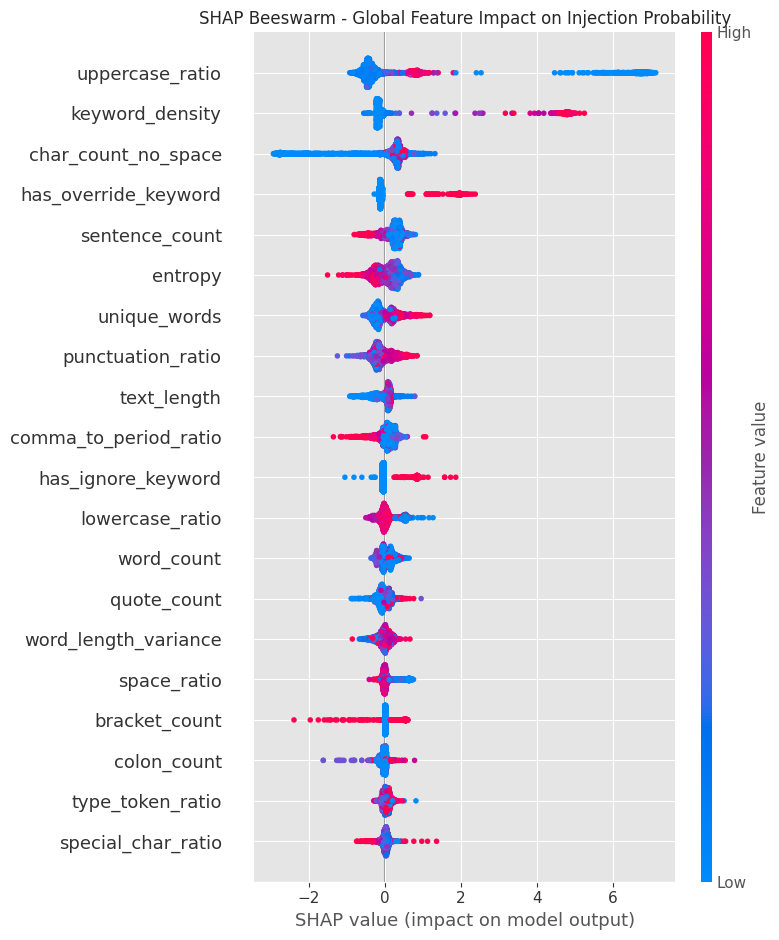

SHAP beeswarm saved: /home/linkezio/Projects/IA-SI/models/shap_beeswarm.png

--- SHAP Waterfall: Highest-confidence INJECTION (score=1.0000) ---


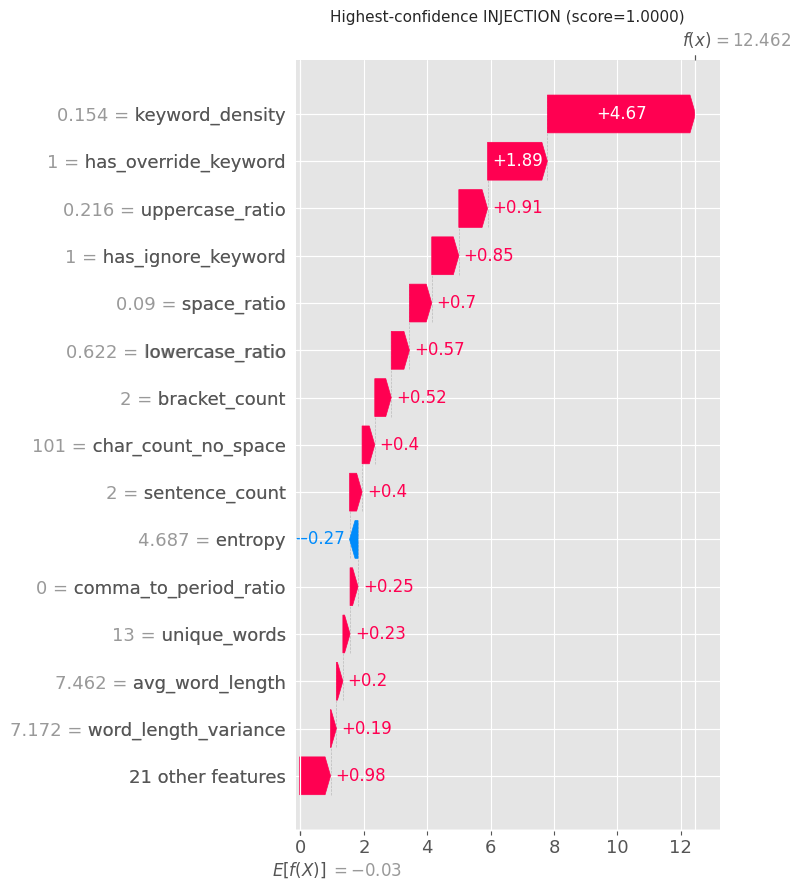


--- SHAP Waterfall: Highest-confidence BENIGN    (score=0.0016) ---


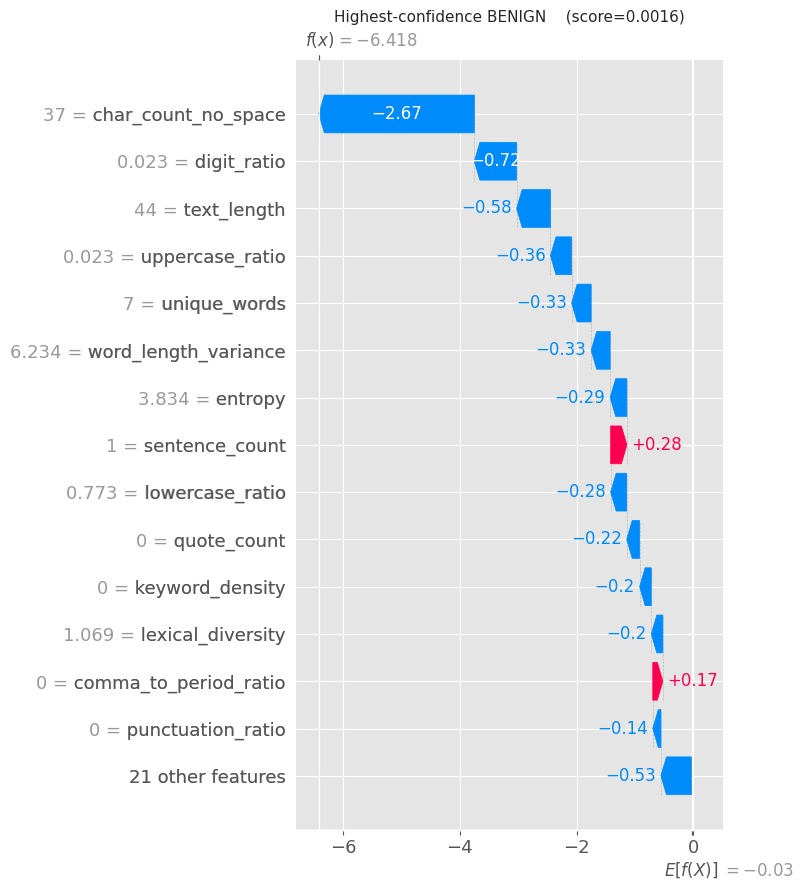


--- SHAP Waterfall: Most UNCERTAIN               (score=0.5001) ---


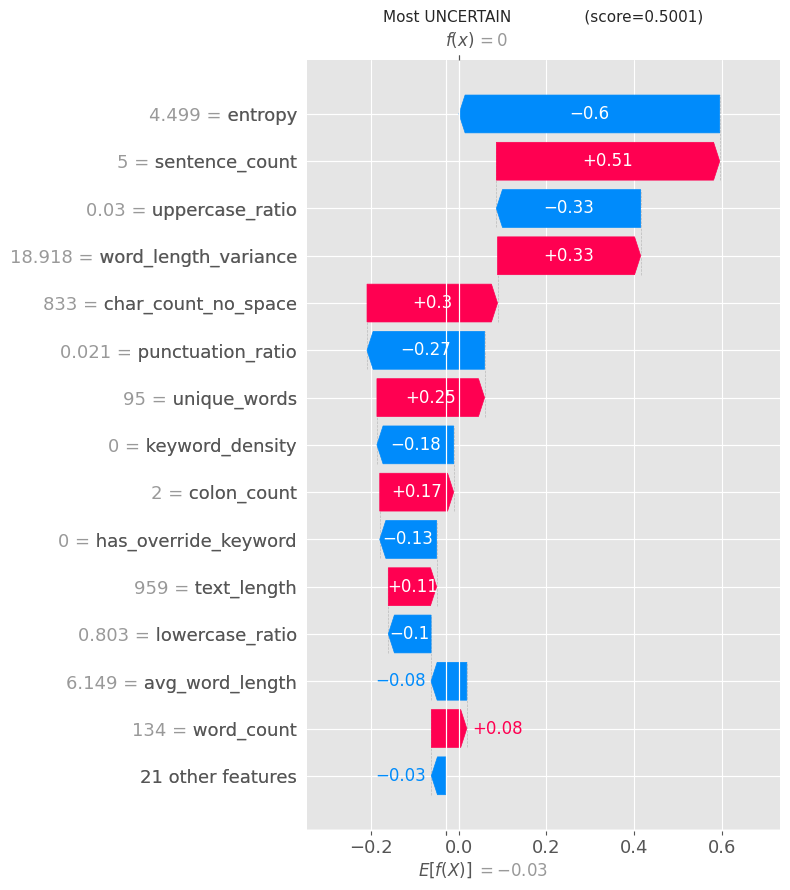

In [10]:
# CELL 10: Feature Importance & SHAP
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('XGBoost Feature Importance', fontsize=14, fontweight='bold')
for ax, imp_type in zip(axes, ['gain', 'weight', 'cover']):
    raw_imp = final_model.get_booster().get_score(importance_type=imp_type)
    imp_df = pd.DataFrame({'feature': list(raw_imp.keys()), 'importance': list(raw_imp.values())})
    imp_df = imp_df.sort_values('importance', ascending=True).tail(20)
    ax.barh(range(len(imp_df)), imp_df['importance'], color='steelblue', edgecolor='white')
    ax.set_yticks(range(len(imp_df))); ax.set_yticklabels(imp_df['feature'], fontsize=9)
    ax.set_title(f'By {imp_type.capitalize()}'); ax.set_xlabel('Importance'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
imp_path = os.path.join(CONFIG['models_dir'], 'feature_importance.png')
plt.savefig(imp_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'Feature importance saved: {imp_path}')

print('Computing SHAP values on 2,000-sample subset...')
shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=CONFIG['seed'])
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(shap_sample)
shap_exp    = explainer(shap_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, plot_type='dot', max_display=20, show=False)
plt.title('SHAP Beeswarm - Global Feature Impact on Injection Probability', fontsize=12)
plt.tight_layout()
shap_bees_path = os.path.join(CONFIG['models_dir'], 'shap_beeswarm.png')
plt.savefig(shap_bees_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'SHAP beeswarm saved: {shap_bees_path}')

sample_proba  = final_model.predict_proba(shap_sample)[:, 1]
idx_high_inj  = int(np.argmax(sample_proba))
idx_high_ben  = int(np.argmin(sample_proba))
idx_uncertain = int(np.argmin(np.abs(sample_proba - 0.5)))
cases = [
    (idx_high_inj,  f'Highest-confidence INJECTION (score={sample_proba[idx_high_inj]:.4f})'),
    (idx_high_ben,  f'Highest-confidence BENIGN    (score={sample_proba[idx_high_ben]:.4f})'),
    (idx_uncertain, f'Most UNCERTAIN               (score={sample_proba[idx_uncertain]:.4f})'),
]
for idx, title in cases:
    print(f'\n--- SHAP Waterfall: {title} ---')
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_exp[idx], max_display=15, show=False)
    plt.title(title, fontsize=11); plt.tight_layout(); plt.show()


In [11]:
# CELL 11: Save All Artifacts
os.makedirs(CONFIG['models_dir'], exist_ok=True)

model_path = os.path.join(CONFIG['models_dir'], 'xgboost_model.json')
final_model.save_model(model_path)
print(f'Model saved:   {model_path}')

params_path = os.path.join(CONFIG['models_dir'], 'best_params.json')
with open(params_path, 'w') as f:
    json.dump(study.best_params, f, indent=2)
print(f'Params saved:  {params_path}')

metrics_dict = {
    'auc_roc': float(auc_roc), 'auc_pr': float(auc_pr),
    'accuracy': float(acc), 'precision': float(prec),
    'recall': float(rec), 'f1': float(f1),
    'n_test_samples': int(len(y_test)),
    'n_estimators_used': int(final_model.best_iteration),
    'optuna_best_cv_auc': float(study.best_value),
    'n_trials_completed': sum(1 for t in study.trials if t.value is not None),
    'confusion_matrix': {'TN': int(cm[0,0]), 'FP': int(cm[0,1]), 'FN': int(cm[1,0]), 'TP': int(cm[1,1])},
}
metrics_path = os.path.join(CONFIG['models_dir'], 'evaluation_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2)
print(f'Metrics saved: {metrics_path}')

study_path = os.path.join(CONFIG['models_dir'], 'optuna_study.pkl')
with open(study_path, 'wb') as f:
    pickle.dump(study, f)
print(f'Study saved:   {study_path}')

print('=' * 56)
print('TRAINING COMPLETE')
print('=' * 56)
print(f'  AUC-ROC (primary): {auc_roc:.6f}')
print(f'  AUC-PR:            {auc_pr:.6f}')
print(f'  F1 Score:          {f1:.6f}')
print(f'  Accuracy:          {acc:.6f}')
print(f'  Trees used:        {final_model.best_iteration}')
print(f'  Optuna CV AUC:     {study.best_value:.6f}')
print(f'\nArtifacts in {CONFIG["models_dir"]}/')
for fname in ['xgboost_model.json','best_params.json','evaluation_metrics.json',
              'optuna_study.pkl','evaluation_plots.png','feature_importance.png','shap_beeswarm.png']:
    fpath = os.path.join(CONFIG['models_dir'], fname)
    size_kb = os.path.getsize(fpath)/1024 if os.path.exists(fpath) else 0
    print(f'  {fname:<35} {size_kb:.1f} KB' if size_kb > 0 else f'  {fname:<35} MISSING!')


Model saved:   /home/linkezio/Projects/IA-SI/models/xgboost_model.json
Params saved:  /home/linkezio/Projects/IA-SI/models/best_params.json
Metrics saved: /home/linkezio/Projects/IA-SI/models/evaluation_metrics.json
Study saved:   /home/linkezio/Projects/IA-SI/models/optuna_study.pkl
TRAINING COMPLETE
  AUC-ROC (primary): 0.918043
  AUC-PR:            0.928564
  F1 Score:          0.814202
  Accuracy:          0.826552
  Trees used:        2397
  Optuna CV AUC:     0.918307

Artifacts in /home/linkezio/Projects/IA-SI/models/
  xgboost_model.json                  46811.2 KB
  best_params.json                    0.3 KB
  evaluation_metrics.json             0.4 KB
  optuna_study.pkl                    66.9 KB
  evaluation_plots.png                309.2 KB
  feature_importance.png              205.8 KB
  shap_beeswarm.png                   211.5 KB


In [12]:
# CELL 12: Model Round-Trip Smoke Test
_loaded = xgb.XGBClassifier()
_loaded.load_model(os.path.join(CONFIG['models_dir'], 'xgboost_model.json'))
_check_proba = _loaded.predict_proba(X_test[:5])[:, 1]
assert len(_check_proba) == 5
print('Model round-trip load OK')
print('First 5 probabilities:', _check_proba.round(4))


Model round-trip load OK
First 5 probabilities: [0.1244 0.5339 0.9999 1.     1.    ]
